# Lecture 21:[link text](https://) **Curve Fitting and the Method of Least Squares**
**Topic:** Statistical Methods - Data Crunching & Curve Fitting

---

## **1. Introduction: Interpolation vs. Curve Fitting**

In previous lectures, we discussed **Interpolation** (like Lagrange and Splines). Interpolation is used when we trust our data points absolutely, and we want to draw a curve that passes **exactly** through every single point.

However, in real-world physics and astronomy, data is messy. Telescopes have sensor noise, atmospheric interference, and systemic errors. If we force a curve through every noisy data point, we end up fitting the *noise*, not the *physics*.

**Curve Fitting** takes a different approach. We assume an underlying physical mathematical model (e.g., a straight line, a Gaussian, or an exponential decay) and we try to find the specific parameters that make our model "best fit" the overall trend of the data, even if it doesn't perfectly touch any individual point.


## **2. The Method of Least Squares**

How do we mathematically define the "best fit"?

Suppose we have $N$ data points $(x_i, y_i)$. We propose a mathematical model $f(x)$ to fit this data. For every data point $x_i$, our model predicts a value $f(x_i)$.

The difference between the actual observed value $y_i$ and the predicted value $f(x_i)$ is called the **Residual** ($r_i$):
$$r_i = y_i - f(x_i)$$

We want to minimize these residuals. But we cannot just sum them up, because positive and negative residuals would cancel each other out. Instead, we square them.

The **Sum of Squared Residuals ($S$)** is:
$$S = \sum_{i=1}^{N} [y_i - f(x_i)]^2$$

**The Least Squares Principle:** The "best fit" curve is the one that minimizes the total sum of the squared residuals ($S$).


## **3. Analytical Solution for Linear Least Squares**

Let's apply this to the simplest model: a straight line.
$$f(x) = mx + c$$

Our sum of squared residuals becomes:
$$S(m, c) = \sum_{i=1}^{N} (y_i - (mx_i + c))^2$$

To find the minimum of $S$, we use calculus. We take the partial derivatives of $S$ with respect to our unknown parameters ($m$ and $c$) and set them to zero:
$$\frac{\partial S}{\partial m} = 0 \quad \text{and} \quad \frac{\partial S}{\partial c} = 0$$

Solving this system of two linear equations yields the exact analytical formulas for the optimal slope ($m$) and intercept ($c$):

$$m = \frac{N \sum(x_i y_i) - \sum(x_i) \sum(y_i)}{N \sum(x_i^2) - (\sum x_i)^2}$$

$$c = \frac{\sum(y_i) - m \sum(x_i)}{N}$$

Let's implement this analytical formula in Python from scratch.



### **Manual Calculation: Linear Least Squares Fit**

**The Goal:**
Fit a straight line, $y = mx + c$, to a set of noisy data points by minimizing the sum of the squared residuals.

**The Formulas:**
* **Slope ($m$):** $$m = \frac{N(\sum xy) - (\sum x)(\sum y)}{N(\sum x^2) - (\sum x)^2}$$
* **Intercept ($c$):** $$c = \frac{\sum y - m(\sum x)}{N}$$
*(Where $N$ is the total number of data points).*

---

#### **Step 1: The Data**
We have $N = 4$ data points: $(1, 2), (2, 3), (3, 5), \text{ and } (4, 4)$.

#### **Step 2: The Calculation Table**
Calculate $x^2$ and $x \cdot y$ for each point, then sum the columns.

| Point ($i$) | $x$ | $y$ | $x^2$ | $x \cdot y$ |
| :---: | :---: | :---: | :---: | :---: |
| 1 | 1 | 2 | 1 | 2 |
| 2 | 2 | 3 | 4 | 6 |
| 3 | 3 | 5 | 9 | 15 |
| 4 | 4 | 4 | 16 | 16 |
| **SUMS ($\sum$)**| **10** | **14** | **30** | **39** |

#### **Step 3: Calculate the Slope ($m$)**
Substitute the sums into the slope formula:
* $N = 4$
* $\sum x = 10$
* $\sum y = 14$
* $\sum x^2 = 30$
* $\sum xy = 39$

$$m = \frac{4(39) - (10)(14)}{4(30) - (10)^2}$$

$$m = \frac{156 - 140}{120 - 100}$$

$$m = \frac{16}{20} = \mathbf{0.8}$$

#### **Step 4: Calculate the Intercept ($c$)**
Substitute the sums and our calculated slope ($m = 0.8$) into the intercept formula:

$$c = \frac{14 - 0.8(10)}{4}$$

$$c = \frac{14 - 8}{4}$$

$$c = \frac{6}{4} = \mathbf{1.5}$$

#### **Final Result**
The line of best fit that minimizes the squared errors is:
**$$y = 0.8x + 1.5$$**


Analytical Fit Results:
Slope (m): 1.9743
Intercept (c): 0.1400


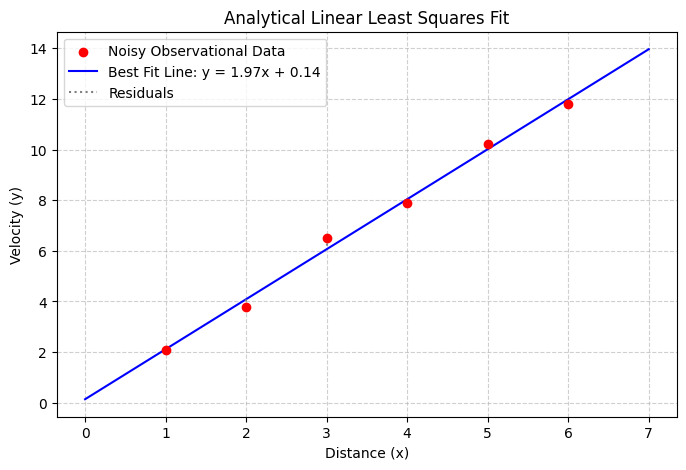

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Create some noisy data (e.g., measuring Hubble's Law: Velocity vs Distance)
x_data = np.array([1.0, 2.0, 3.0, 4.0, 5.0, 6.0])
y_data = np.array([2.1, 3.8, 6.5, 7.9, 10.2, 11.8]) # Roughly y = 2x, but with noise
N = len(x_data)

# 2. Calculate the required sums for the analytical formula
sum_x = np.sum(x_data)
sum_y = np.sum(y_data)
sum_xy = np.sum(x_data * y_data)
sum_x2 = np.sum(x_data**2)

# 3. Apply the Least Squares Analytical Formulas
m = (N * sum_xy - sum_x * sum_y) / (N * sum_x2 - sum_x**2)
c = (sum_y - m * sum_x) / N

print(f"Analytical Fit Results:")
print(f"Slope (m): {m:.4f}")
print(f"Intercept (c): {c:.4f}")

# 4. Generate the fit line for plotting
x_fit = np.linspace(0, 7, 100)
y_fit = m * x_fit + c

# 5. Plotting
plt.figure(figsize=(8, 5))
plt.scatter(x_data, y_data, color='red', label='Noisy Observational Data', zorder=5)
plt.plot(x_fit, y_fit, 'b-', label=f'Best Fit Line: y = {m:.2f}x + {c:.2f}')
plt.vlines(x_data, y_data, m*x_data + c, colors='gray', linestyles='dotted', label='Residuals')
plt.title('Analytical Linear Least Squares Fit')
plt.xlabel('Distance (x)')
plt.ylabel('Velocity (y)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


## **4. Non-Linear Fitting with Python (`scipy.optimize`)**

The analytical formulas above only work for linear equations (or equations that can be linearized via logarithms, like $y = Ae^{bx} \rightarrow \ln(y) = \ln(A) + bx$).

What if we want to fit a complex, non-linear physical model? For example, fitting a **Gaussian profile** to a star's spectral emission line, or fitting a sine wave to a pulsating variable star.

For this, we use iterative computational solvers. The most powerful tool for this in Python is `scipy.optimize.curve_fit`. It uses the **Levenberg-Marquardt algorithm**, which is a highly advanced method for solving non-linear least squares problems.

### **Example: Fitting an Exponential Decay**
Imagine we are tracking the brightness of a supernova remnant over time, which follows an exponential decay:
$$F(t) = A e^{-\lambda t} + C$$
Where $A$ is initial amplitude, $\lambda$ is the decay rate, and $C$ is background noise.

--- Scipy curve_fit Results ---
Fitted Amplitude (A): 16.146
Fitted Decay Rate (lambda): 0.528
Fitted Background (C): 1.703

Uncertainty in A: +/- 0.543
Uncertainty in decay: +/- 0.038


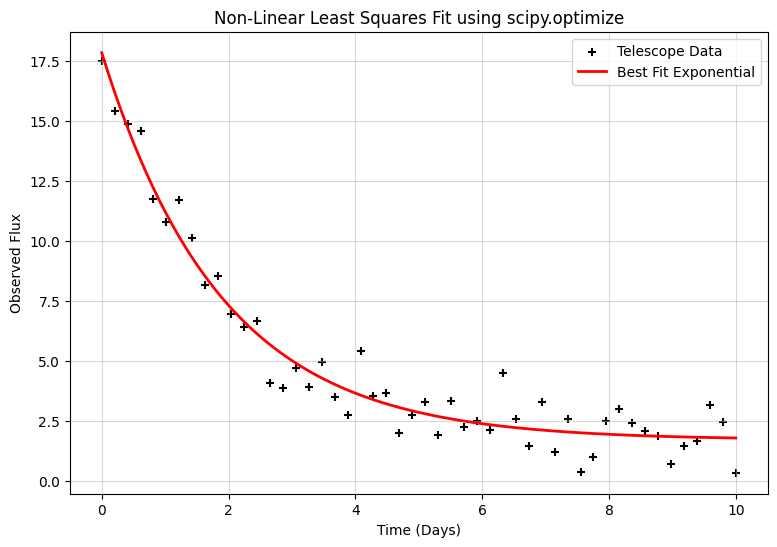

In [ ]:
from scipy.optimize import curve_fit

# 1. Define our physical model (The function we want to fit)
def exponential_model(t, A, decay_rate, C):
    return A * np.exp(-decay_rate * t) + C

# 2. Generate Fake "Observational" Data with Random Noise
np.random.seed(42) # For reproducible results
time_data = np.linspace(0, 10, 50)
# True parameters: A=15.0, decay=0.5, C=2.0
true_flux = exponential_model(time_data, 15.0, 0.5, 2.0)
noise = np.random.normal(0, 1.0, len(time_data)) # Gaussian noise
flux_data = true_flux + noise

# 3. Perform the Curve Fit
# curve_fit requires: the model function, the x_data, the y_data, and optionally an initial guess (p0)
initial_guess = [10.0, 0.1, 0.0] # [A_guess, decay_guess, C_guess]

optimal_parameters, covariance_matrix = curve_fit(exponential_model, time_data, flux_data, p0=initial_guess)

A_opt, decay_opt, C_opt = optimal_parameters

print("--- Scipy curve_fit Results ---")
print(f"Fitted Amplitude (A): {A_opt:.3f}")
print(f"Fitted Decay Rate (lambda): {decay_opt:.3f}")
print(f"Fitted Background (C): {C_opt:.3f}")

# 4. Calculate Errors (Standard Deviations) from the Covariance Matrix
# The diagonal of the covariance matrix contains the variance of the parameters.
parameter_errors = np.sqrt(np.diag(covariance_matrix))
print(f"\nUncertainty in A: +/- {parameter_errors[0]:.3f}")
print(f"Uncertainty in decay: +/- {parameter_errors[1]:.3f}")

# 5. Plotting
plt.figure(figsize=(9, 6))
plt.scatter(time_data, flux_data, color='black', marker='+', label='Telescope Data')

# Generate smooth curve for plotting
t_smooth = np.linspace(0, 10, 200)
flux_fit = exponential_model(t_smooth, A_opt, decay_opt, C_opt)

plt.plot(t_smooth, flux_fit, 'r-', lw=2, label='Best Fit Exponential')
plt.title('Non-Linear Least Squares Fit using scipy.optimize')
plt.xlabel('Time (Days)')
plt.ylabel('Observed Flux')
plt.legend()
plt.grid(True, alpha=0.5)
plt.show()


### **Understanding the Covariance Matrix (`pcov`) in `scipy.optimize`**

When you use `scipy.optimize.curve_fit` to fit a model to your data, it returns two main arrays:
1. `popt`: The **o**ptimal **p**arameters that minimize the sum of squared residuals.
2. `pcov`: The **cov**ariance matrix of those parameters.

The **covariance matrix** is a fundamental concept in statistics that tells you how much uncertainty there is in your fitted parameters, and how the parameters interact with each other.

If your model has $k$ parameters, `pcov` will be a $k \times k$ matrix. Let's assume you are fitting a simple line $y = mx + c$. You have 2 parameters ($m$ and $c$), so `pcov` is a $2 \times 2$ matrix:

$$
\text{pcov} = \begin{bmatrix}
\text{Var}(m) & \text{Cov}(m, c) \\
\text{Cov}(c, m) & \text{Var}(c)
\end{bmatrix}
$$

#### **1. The Diagonals (Parameter Variance)**
The main diagonal contains the **Variance** ($\sigma^2$) of each parameter. This is the most practically useful part of the matrix. To find the standard error (uncertainty) of your fitted parameters, you take the square root of these diagonal elements:
* $\Delta m = \sqrt{\text{pcov}[0, 0]}$
* $\Delta c = \sqrt{\text{pcov}[1, 1]}$

If the variance is large, it means the data is too noisy or sparse for the algorithm to confidently pin down that specific parameter.

#### **2. The Off-Diagonals (Parameter Covariance)**
The off-diagonal elements tell you how strongly the errors in the parameters are **correlated**.
* If $\text{Cov}(m, c)$ is a large positive number, it means if the algorithm slightly overestimated the slope ($m$), it probably also overestimated the intercept ($c$).
* If it is a large negative number, overestimating one leads to underestimating the other.
* If these values are extremely high relative to the diagonals, it often indicates your model is **over-parameterized** (e.g., trying to fit a 5th-degree polynomial to 4 data points), and multiple parameters are fighting to do the same job.

---

### **Goodness-of-Fit Parameters**

Just because `curve_fit` gives you an answer doesn't mean it's a *good* answer. To evaluate how well your model actually describes the data, we use "Goodness-of-Fit" statistical metrics.

#### **1. Sum of Squared Residuals (SSR or RSS)**
This is the raw value that the Least Squares method actively tries to minimize.
$$\text{RSS} = \sum_{i=1}^{N} (y_i - f(x_i))^2$$
* **Interpretation:** Lower is better. However, it is scale-dependent. An RSS of $100$ might be fantastic if your data values are in the millions, but terrible if your data values are between 0 and 1.

#### **2. R-squared ($R^2$) - Coefficient of Determination**
This metric normalizes the residuals against the natural variance of the data itself. It compares your fit to the simplest possible model: a flat horizontal line drawn at the mean of the data ($\bar{y}$).
$$R^2 = 1 - \frac{\text{RSS}}{\text{Total Sum of Squares (TSS)}} = 1 - \frac{\sum (y_i - f(x_i))^2}{\sum (y_i - \bar{y})^2}$$
* **Interpretation:** $R^2$ ranges from $0$ to $1$.
    * $R^2 = 1.0$: A perfect fit (the curve passes exactly through every point).
    * $R^2 = 0.0$: Your model is no better than just guessing the average value of the dataset.
* *Caution in Astrophysics:* $R^2$ is technically only mathematically valid for *linear* models, though it is frequently calculated for non-linear models as a rough heuristic.

#### **3. Reduced Chi-Squared ($\chi^2_\nu$)**
This is the **gold standard** for goodness-of-fit in experimental physics and astronomy. Unlike $R^2$, it explicitly incorporates the measurement uncertainty (error bars, $\sigma_i$) of your data points, and penalizes you for adding too many parameters (Degrees of Freedom, $\nu$).
$$\chi^2_\nu = \frac{1}{\nu} \sum_{i=1}^{N} \frac{(y_i - f(x_i))^2}{\sigma_i^2}$$
Where $\nu = N - p$ (Number of data points minus the number of fitted parameters).
* **Interpretation:**
    * $\chi^2_\nu \approx 1$: **A perfect physical fit.** The scatter of the data around your curve perfectly matches the expected noise of your instruments.
    * $\chi^2_\nu \gg 1$: **Poor fit.** Your model doesn't capture the trend, or you have vastly underestimated the noise in your data.
    * $\chi^2_\nu \ll 1$: **Overfitting.** You have too many parameters fitting the noise, or you have overestimated the error bars of your instruments.

---
### **Interactive Exploration**
To build intuition for how these metrics and the covariance react to noisy data, try adjusting the parameters in the interactive simulation below. Notice how increasing the noise blows up the parameter uncertainties (derived from the covariance matrix) and degrades the $R^2$ score.



### **Why is `curve_fit` so important in research?**
Notice the **Covariance Matrix** in the code above. In physics, an answer without an error bound is meaningless. `scipy` not only finds the best-fit parameters, but it also provides the statistical uncertainty (standard deviation) for each parameter based on how noisy the original data was. This is crucial for publishing scientific results.

# **Computational Astrophysics: Assignment on Curve Fitting**

**Instructions:**
For each of the following problems, write a Python script using `scipy.optimize.curve_fit` (or analytical methods where appropriate) to fit the given physical model to the observational data.

For **every** problem, your output must explicitly print:
1. The **Best-Fit Parameters** (with appropriate units).
2. The **Standard Error (Uncertainty)** for each parameter (derived from the covariance matrix).
3. The specified **Goodness-of-Fit** parameter ($R^2$, RSS, or Reduced $\chi^2$).

---

### **Problem 1: The Expansion of the Universe (Linear Fit)**
**Context:** In 1929, Edwin Hubble observed that galaxies are receding from us at velocities proportional to their distance. This relationship is governed by Hubble's Law: $v = H_0 \cdot d$, where $v$ is the recessional velocity, $d$ is the distance, and $H_0$ is the Hubble Constant.
**The Model:** $y = mx$ (Note: the intercept is physically constrained to be 0).
**Goodness-of-Fit Required:** Coefficient of Determination ($R^2$).

**The Dataset:**
```python
import numpy as np

# Distance to galaxies in Megaparsecs (Mpc)
distances_mpc = np.array([16.0, 32.0, 48.0, 64.0, 80.0, 96.0, 112.0, 128.0])

# Recessional velocities in km/s (with instrumental noise)
velocities_kms = np.array([1050, 2180, 3400, 4350, 5700, 6650, 8100, 8800])
```

---

### **Problem 2: Kepler's Third Law of Exoplanets (Power-Law Fit)**
**Context:** Kepler's Third Law states that the square of an orbital period ($P$) is proportional to the cube of the semi-major axis ($a$). For a newly discovered exoplanetary system, we can write this as a generalized power law: $P = k \cdot a^n$. If Kepler's laws hold true, $n$ should be exactly $1.5$.
**The Model:** $f(a) = k \cdot a^n$.
**Goodness-of-Fit Required:** Residual Sum of Squares (RSS).

**The Dataset:**
```python
# Semi-major axis in Astronomical Units (AU)
semi_major_axis_au = np.array([0.015, 0.038, 0.065, 0.120, 0.250, 0.510])

# Orbital period in Earth days
periods_days = np.array([0.65, 2.55, 5.80, 14.50, 43.80, 128.00])
```

---

### **Problem 3: Supernova Light Curve Tail (Exponential Decay)**
**Context:** Months after a Type Ia Supernova explodes, its luminosity is entirely powered by the radioactive decay of Cobalt-56 into Iron-56. The light curve tail follows an exponential decay model: $F(t) = F_0 e^{-t/\tau} + C$, where $\tau$ is the characteristic lifetime of the isotope and $C$ is background sky noise.
**The Model:** $f(t) = A e^{-t/\tau} + C$.
**Goodness-of-Fit Required:** Reduced Chi-Squared ($\chi^2_\nu$). Assume every flux measurement has an observational uncertainty (error bar) of $\sigma_i = 0.02$.

**The Dataset:**
```python
# Time elapsed since peak brightness (in days)
time_days = np.array([50, 75, 100, 125, 150, 175, 200, 225])

# Relative observed flux (arbitrary units)
flux_observed = np.array([0.65, 0.52, 0.40, 0.31, 0.25, 0.20, 0.16, 0.13])

# Instrumental error for each measurement
flux_errors = np.full(len(flux_observed), 0.02)
```

---

### **Problem 4: H-Alpha Emission Line Broadening (Gaussian Fit)**
**Context:** You are observing a distant gas cloud. The Hydrogen-Alpha emission line (rest wavelength $\lambda_0 = 6562.8$ Å) is broadened by the thermal motion of the gas (Doppler broadening). The line profile can be modeled as a Gaussian function superimposed on a flat continuum background.
**The Model:** $F(\lambda) = A \exp\left(-\frac{(\lambda - \lambda_c)^2}{2\sigma^2}\right) + C$
**Task Add-on:** After finding the standard deviation ($\sigma$) of the curve, calculate the velocity dispersion of the gas using $v_{disp} = c \cdot (\sigma / \lambda_c)$, where $c$ is the speed of light.
**Goodness-of-Fit Required:** Coefficient of Determination ($R^2$).

**The Dataset:**
```python
# Wavelength in Angstroms
wavelength_A = np.array([6556.0, 6558.0, 6560.0, 6562.0, 6564.0, 6566.0, 6568.0, 6570.0])

# Measured flux density
flux_density = np.array([1.2, 1.5, 4.2, 8.5, 8.1, 3.8, 1.4, 1.1])
```

---

### **Problem 5: Hot Jupiter Radial Velocity (Sinusoidal Fit)**
**Context:** As a "Hot Jupiter" orbits its host star, its gravity pulls on the star, causing the star to wobble. We detect this wobble as a periodic shift in the star's radial velocity (RV) over time.
**The Model:** $v_r(t) = K \sin\left(\frac{2\pi}{P} t + \phi\right) + \gamma$
*Where $K$ is the velocity amplitude, $P$ is the orbital period, $\phi$ is the phase shift, and $\gamma$ is the systemic velocity of the star relative to Earth.*
**Goodness-of-Fit Required:** Reduced Chi-Squared ($\chi^2_\nu$). Assume an incredibly precise spectrograph giving an uncertainty of $\sigma_i = 2.0$ m/s for each point.

*(Hint: Trigonometric fits are highly sensitive to your initial guess `p0`. Plot the raw data first to estimate the period $P$ and amplitude $K$ before running the fit!)*

**The Dataset:**
```python
# Observation time in days
t_obs = np.array([0.5, 1.2, 1.9, 2.6, 3.3, 4.0, 4.7, 5.4, 6.1, 6.8])

# Radial Velocity in meters per second (m/s)
rv_ms = np.array([32.5, 54.1, 21.0, -30.2, -56.5, -28.1, 25.5, 55.8, 32.0, -22.4])

# Spectrograph error per measurement (m/s)
rv_errors = np.full(len(rv_ms), 2.0)
```

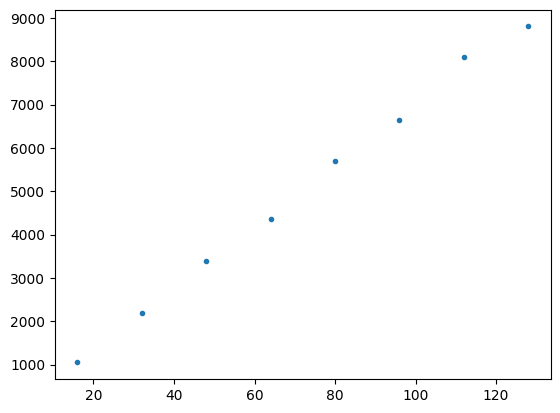

In [ ]:
# Solution 1

import numpy as np

# Distance to galaxies in Megaparsecs (Mpc)
distances_mpc = np.array([16.0, 32.0, 48.0, 64.0, 80.0, 96.0, 112.0, 128.0])

# Recessional velocities in km/s (with instrumental noise)
velocities_kms = np.array([1050, 2180, 3400, 4350, 5700, 6650, 8100, 8800])


import matplotlib.pyplot as plt

plt.plot(distances_mpc, velocities_kms, '.')